# Strategy Search and the Measurement of Overfitting

**Master's Thesis in Data Science - Chapter 5.9: what search actually buys**

Notebooks `02` and `03` built an apparatus that cannot look ahead and does not flatter itself. This
notebook turns that apparatus loose on an actual **search**, and then measures the one thing a search
inevitably manufactures: **selection optimism**.

The distinction at the heart of this chapter is simple to state and easy to forget. A candidate's
validation score is the number that *caused it to be selected*. Its test score is the number it
*earns*. If the two differ systematically, the difference is not noise - it is the price of having
chosen. This notebook measures that price on 3,000 real fold winners from the closed R3 study.

## 1. Executive summary

**Objective.** Quantify how much of a searched strategy's apparent performance is genuine structure
and how much is the arithmetic consequence of selecting the maximum of many noisy estimates.

**The central result.** Across every family, every asset, every seed and both search engines, the
validation Sharpe of a selected candidate is a **strongly biased** estimate of the Sharpe it goes on
to earn: the average winner is selected at a validation Sharpe above 3 and earns a *negative* Sharpe
on test. The bias is large, it is systematic rather than random, and it does not shrink when a more
sophisticated search algorithm is used - because the bias comes from *selecting*, not from *how* one
selects.

**What is analysed here.**

| # | Question | Evidence |
|---|----------|----------|
| S1 | How large is the search space relative to the budget spent on it? | `search_space.json` per family |
| S2 | How optimistic is a validation score as a predictor of test performance? | 3,000 fold winners, val vs test |
| S3 | Does the optimism differ between Random Search and the Genetic Algorithm? | Paired, budget-matched |
| S4 | Did both engines really receive an identical budget? | Per-fold parity audit |
| S5 | How much does the result move if only the random seed changes? | 10 seeds per unit |
| S6 | What does the search converge to, and how fast? | Per-fold convergence traces |

**Provenance.** All evidence comes from the closed R3 study,
`artifacts/runs/r3_full_budget100_ga21/`: five strategy families, two assets, ten derived seeds,
fifteen isolated outer folds, one hundred unique evaluations per fold and per engine. Every run used
the corrected `independent_search_per_outer_fold` protocol
([ADR 0012](../docs/decisions/0012-outer-fold-contamination-in-candidate-search.md)); results
produced before that correction are marked `SUPERSEDED` on disk and are not read here.

**The frozen holdout is not touched.** Every number below is computed on development-period walk-forward
test slices, which are out of sample with respect to selection but are *not* the holdout.

## 2. Loading the study evidence

**Method.** Each family's `study_manifest.json` maps 20 units - a `(symbol, seed)` grid - to the run
directory that produced them. Every run stores, for each engine and each of the fifteen outer folds,
the candidate that won that fold's **validation** window, the validation Sharpe that won it, and the
metrics obtained when that frozen candidate was scored **once** on the fold's test slice.

That structure is what makes the measurement possible: the selection score and the honest score are
recorded separately, for the same candidate, on the same fold.

In [1]:
import os
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
REPO_ROOT = _root
print(f"Repository root: {REPO_ROOT}")

Repository root: C:\Users\alexc\OneDrive\Escritorio\tfm_algorithmic_trading


In [2]:
import json
import platform
from itertools import product

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.stats as sstats
from IPython.display import display

from perp_lab import __version__ as perp_lab_version
from perp_lab.config import Paths, load_experiment_config
from perp_lab.reporting import ArtifactContext, apply_house_style, save_figure, save_table

apply_house_style()
EXP = load_experiment_config()
PATHS = Paths()
FIG_DPI = 300

STUDY_ROOT = Path("artifacts/runs/r3_full_budget100_ga21")
ENGINES = ("random_search", "genetic_algorithm")
ENGINE_LABEL = {"random_search": "Random Search", "genetic_algorithm": "Genetic Algorithm"}
ENGINE_COLOR = {"random_search": "#0072B2", "genetic_algorithm": "#D55E00"}

print("Environment")
print(f"  Python   : {platform.python_version()} | perp_lab {perp_lab_version}")
print(
    f"  polars   : {pl.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}"
)
print(f"  study    : {STUDY_ROOT}")
print(f"  exists   : {STUDY_ROOT.exists()}")

FAMILIES = sorted(p.name for p in STUDY_ROOT.iterdir() if p.is_dir())
print(f"  families : {FAMILIES}")

Environment
  Python   : 3.12.3 | perp_lab 0.1.0
  polars   : 1.43.1 | numpy 2.5.1 | matplotlib 3.11.1
  study    : artifacts\runs\r3_full_budget100_ga21
  exists   : True
  families : ['BTC_ETH_confirmation', 'breakout', 'funding', 'mean_reversion', 'volatility_breakout']


In [3]:
NB_ID = "04_strategy_search_and_overfitting"
ctx = ArtifactContext(
    notebook=NB_ID,
    figures_dir=PATHS.reports_root / "figures" / "search",
    tables_dir=PATHS.reports_root / "tables" / "search",
    metadata_dir=PATHS.reports_root / "metadata" / "search",
    config={
        "study_root": str(STUDY_ROOT),
        "families": FAMILIES,
        "engines": list(ENGINES),
        "experiment_version": EXP.version,
    },
    period="development walk-forward test slices (no holdout row enters this notebook)",
    repo_root=".",
)


def show(fig, name, caption=""):
    save_figure(fig, name, ctx, caption=caption, dpi=FIG_DPI)
    display(fig)
    plt.close(fig)


# --- Assemble the fold-winner evidence into one tidy frame -------------------
rows: list[dict] = []
unit_rows: list[dict] = []
for family in FAMILIES:
    manifest = json.loads((STUDY_ROOT / family / "study_manifest.json").read_text(encoding="utf-8"))
    for unit in manifest["units"].values():
        run_dir = Path(str(unit["run_dir"]).replace("\\", "/"))
        unit_rows.append(
            {
                "family": family,
                "symbol": unit["symbol"],
                "seed": unit["seed"],
                "run_id": unit["run_id"],
                "n_folds": unit["n_folds"],
                "protocol": unit["search_protocol"],
            }
        )
        for engine in ENGINES:
            wpath = run_dir / f"{engine}_fold_winners.json"
            if not wpath.exists():
                continue
            for w in json.loads(wpath.read_text(encoding="utf-8")):
                tm = w.get("test_metrics") or {}
                rows.append(
                    {
                        "family": family,
                        "symbol": unit["symbol"],
                        "seed": int(unit["seed"]),
                        "engine": engine,
                        "fold": int(w["fold"]),
                        "val_sharpe": float(w["val_sharpe"]),
                        "test_sharpe": float(tm.get("sharpe", float("nan"))),
                        "test_total_return": float(tm.get("total_return", float("nan"))),
                        "test_max_drawdown": float(tm.get("max_drawdown", float("nan"))),
                        "test_n_trades": float(tm.get("n_trades", float("nan"))),
                        "frozen_before_test": bool(w.get("frozen_before_test", False)),
                        "selection_basis": w.get("selection_basis", ""),
                    }
                )

WINNERS = pl.DataFrame(rows)
UNITS = pl.DataFrame(unit_rows)
print(f"Fold winners loaded : {WINNERS.height:,}")
print(
    f"Units               : {UNITS.height} ({UNITS['family'].n_unique()} families "
    f"x {UNITS['symbol'].n_unique()} symbols x {UNITS['seed'].n_unique()} seeds)"
)
print(f"Protocols present   : {UNITS['protocol'].unique().to_list()}")
print(f"All frozen before test : {bool(WINNERS['frozen_before_test'].all())}")
print(f"Selection basis        : {WINNERS['selection_basis'].unique().to_list()}")
display(WINNERS.head(5))

Fold winners loaded : 3,000
Units               : 100 (5 families x 2 symbols x 10 seeds)
Protocols present   : ['independent_search_per_outer_fold']
All frozen before test : True
Selection basis        : ['validation_only']


family,symbol,seed,engine,fold,val_sharpe,test_sharpe,test_total_return,test_max_drawdown,test_n_trades,frozen_before_test,selection_basis
str,str,i64,str,i64,f64,f64,f64,f64,f64,bool,str
"""BTC_ETH_confirmation""","""BTCUSDT""",891022,"""random_search""",0,1.608565,3.328769,0.554597,-0.146477,57.0,true,"""validation_only"""
"""BTC_ETH_confirmation""","""BTCUSDT""",891022,"""random_search""",1,5.693124,-0.259127,-0.064165,-0.23232,23.0,true,"""validation_only"""
"""BTC_ETH_confirmation""","""BTCUSDT""",891022,"""random_search""",2,2.226115,-3.08425,-0.231222,-0.290085,24.0,true,"""validation_only"""
"""BTC_ETH_confirmation""","""BTCUSDT""",891022,"""random_search""",3,3.1597,-5.757865,-0.379404,-0.407815,95.0,true,"""validation_only"""
"""BTC_ETH_confirmation""","""BTCUSDT""",891022,"""random_search""",4,5.921773,-0.959107,-0.078638,-0.216091,101.0,true,"""validation_only"""


## 3. How large is the space, and how much of it was searched?

**Analytical question.** A search algorithm can only add value if the space is too large to enumerate.
How large is it here? **Method.** Each run stores the exact `search_space.json` it sampled from, with
every parameter's type, choices and conditional activation. We compute the **cardinality** of each
family's space, accounting for conditional parameters that only exist when a gate is enabled, and
compare it against the per-fold evaluation budget.

**Interpretation.** This is the question that determines whether the RS-versus-GA comparison is even
interesting. If the budget approaches the size of the space, both engines end up enumerating nearly
the same set, and any observed difference between them is noise.

In [4]:
def space_cardinality(params: list[dict]) -> int:
    # Exact number of distinct parameterisations, honouring conditional activation:
    # a parameter that only exists when a gate is enabled multiplies only the
    # branch in which that gate is on.
    uncond = [p for p in params if not p.get("active_when")]
    cond = [p for p in params if p.get("active_when")]

    def n_choices(p: dict) -> int:
        if p["type"] == "bool":
            return 2
        if p["type"] == "categorical":
            return len(p["choices"])
        # Integer / float ranges are enumerated on their declared grid when present.
        return len(p.get("choices", [])) or 1

    total = 0
    base_names = [p["name"] for p in uncond]
    for combo in product(*[range(n_choices(p)) for p in uncond]):
        assignment = {}
        for name, p, idx in zip(base_names, uncond, combo, strict=True):
            if p["type"] == "bool":
                assignment[name] = idx == 1
            elif p["type"] == "categorical":
                assignment[name] = p["choices"][idx]
        mult = 1
        for p in cond:
            gate_name, gate_value = p["active_when"]
            if assignment.get(gate_name) == gate_value:
                mult *= n_choices(p)
        total += mult
    return total


space_rows = []
for family in FAMILIES:
    manifest = json.loads((STUDY_ROOT / family / "study_manifest.json").read_text(encoding="utf-8"))
    first = next(iter(manifest["units"].values()))
    run_dir = Path(str(first["run_dir"]).replace("\\", "/"))
    space = json.loads((run_dir / "search_space.json").read_text(encoding="utf-8"))
    summary = json.loads((run_dir / "comparison_summary.json").read_text(encoding="utf-8"))
    card = space_cardinality(space["params"])
    budget = int(summary["budget"])
    space_rows.append(
        {
            "family": family,
            "n_parameters": len(space["params"]),
            "space_cardinality": card,
            "budget_per_fold": budget,
            "coverage_pct": 100.0 * min(budget, card) / card,
            "exhaustive": budget >= card,
        }
    )
SPACE = pl.DataFrame(space_rows).sort("space_cardinality")
save_table(
    SPACE,
    "t01_search_space_vs_budget",
    ctx,
    caption="Exact cardinality of each family's parameter space against the per-fold "
    "evaluation budget.",
)
display(SPACE)
print("\nCoverage of the space by one fold's budget:")
for r in SPACE.iter_rows(named=True):
    print(
        f"   {r['family']:<22}: {r['space_cardinality']:>6,} parameterisations -> "
        f"{r['coverage_pct']:>5.1f}% covered"
    )
print(
    f"\nRange of coverage : {float(SPACE['coverage_pct'].min()):.1f}% .. "
    f"{float(SPACE['coverage_pct'].max()):.1f}%"
)
print(
    "\nNOTE: these cardinalities are computed from the declared parameter grid and are an "
    "upper bound.\nThe audited exact counts, which additionally apply each space's repair and "
    "canonical-hash rules,\nare recorded in ADR 0014 and differ slightly for the largest spaces."
)

family,n_parameters,space_cardinality,budget_per_fold,coverage_pct,exhaustive
str,i64,i64,i64,f64,bool
"""breakout""",5,108,100,92.592593,false
"""mean_reversion""",6,432,100,23.148148,false
"""funding""",8,1296,100,7.716049,false
"""BTC_ETH_confirmation""",9,7776,100,1.286008,false
"""volatility_breakout""",10,8748,100,1.143118,false



Coverage of the space by one fold's budget:
   breakout              :    108 parameterisations ->  92.6% covered
   mean_reversion        :    432 parameterisations ->  23.1% covered
   funding               :  1,296 parameterisations ->   7.7% covered
   BTC_ETH_confirmation  :  7,776 parameterisations ->   1.3% covered
   volatility_breakout   :  8,748 parameterisations ->   1.1% covered

Range of coverage : 1.1% .. 92.6%

NOTE: these cardinalities are computed from the declared parameter grid and are an upper bound.
The audited exact counts, which additionally apply each space's repair and canonical-hash rules,
are recorded in ADR 0014 and differ slightly for the largest spaces.


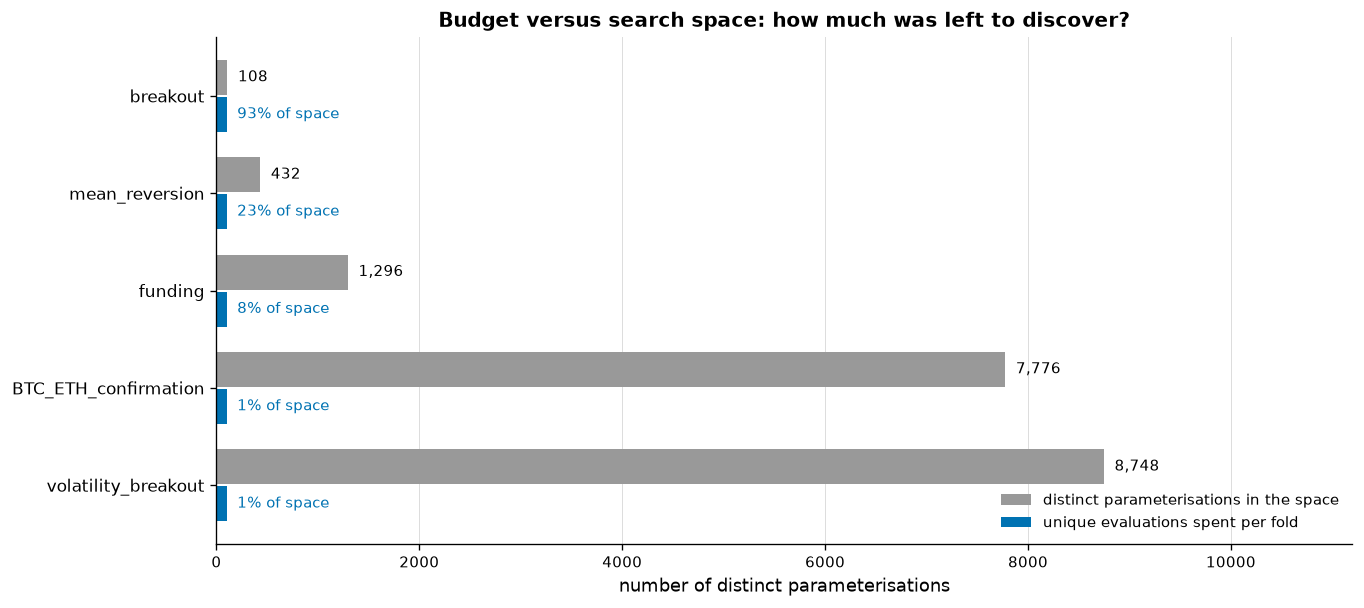

In [5]:
# --- I01: space versus budget -------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 5.2))
fams = SPACE["family"].to_list()
card = SPACE["space_cardinality"].to_numpy()
bud = SPACE["budget_per_fold"].to_numpy()
y = np.arange(len(fams))
ax.barh(
    y - 0.19, card, height=0.36, color="#999999", label="distinct parameterisations in the space"
)
ax.barh(
    y + 0.19,
    np.minimum(bud, card),
    height=0.36,
    color="#0072B2",
    label="unique evaluations spent per fold",
)
for i, (c, b) in enumerate(zip(card, bud, strict=True)):
    ax.text(c + max(card) * 0.012, i - 0.19, f"{c:,}", va="center", fontsize=9)
    ax.text(
        min(b, c) + max(card) * 0.012,
        i + 0.19,
        f"{100 * min(b, c) / c:.0f}% of space",
        va="center",
        fontsize=9,
        color="#0072B2",
    )
ax.set_yticks(y)
ax.set_yticklabels(fams, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, max(card) * 1.28)
ax.set_xlabel("number of distinct parameterisations")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", visible=False)
ax.set_title("Budget versus search space: how much was left to discover?", fontsize=12)
fig.tight_layout()
show(
    fig,
    "i01_space_vs_budget",
    caption="Exact cardinality of each family's parameter space against the per-fold evaluation "
    "budget actually spent.",
)

**Interpretation (3.1).** The spaces are **not uniformly small - they differ by two orders of
magnitude**, and that heterogeneity is the interesting part.

At one extreme, `breakout` has only 108 distinct parameterisations, so a budget of 100 covers almost
the entire space. At the other, `volatility_breakout` and `BTC_ETH_confirmation` have thousands, and
one fold's budget samples barely one percent of them. The other two families sit in between.

Why is the budget then identical across families rather than scaled to each space? Because it had to
be. [ADR 0014](../docs/decisions/0014-r3-budget-bounded-by-search-space.md) records what happened
when it was not: the first R3 launch requested 300 evaluations per fold, Random Search exhausted the
entire breakout space at 108 after sixty thousand proposals, and `BudgetParityError` **aborted the
run**. Three responses were available - widen the breakout space, lower only breakout's budget, or
cap every family at a budget the smallest space can supply. The first two were rejected because
changing a pre-registered space after seeing a failure, or giving families unequal budgets, both
create researcher degrees of freedom. The budget is therefore bounded by the *smallest* space in the
study.

This has an important consequence for how Section 6 must be read, and it runs opposite to the naive
expectation. On the three large families the Genetic Algorithm had **ample room to demonstrate an
advantage**: with only one percent of the space sampled, a search that navigates intelligently should
comfortably beat one that samples blindly. If the GA shows no advantage *there*, the finding cannot
be dismissed as "the space was too small to matter". Only the breakout result carries that caveat.

There is also a quieter benefit for the interpretability goal of this thesis: because these spaces are
enumerable rather than continuous, any surviving rule can be written down in one line and verified by
a reader, which is not true of a model with learned weights.

## 4. Selection optimism: the price of having chosen

**Analytical question.** A candidate is chosen because it had the best validation Sharpe in its fold.
How much of that Sharpe survives on the test slice? **Method.** For all 3,000 fold winners we compare
the **validation Sharpe that selected it** against the **test Sharpe it earned**, with the candidate
frozen and fingerprinted between the two.

This is the cleanest possible measurement of overfitting, because it holds everything else constant:
the same candidate, the same fold, the same engine, the same costs. The only thing that changes is
whether the data was used to choose.

**Interpretation.** If selection were free of bias, the points would scatter symmetrically around the
diagonal. They do not.

In [6]:
W = WINNERS.filter(pl.col("test_sharpe").is_finite() & pl.col("val_sharpe").is_finite())
val = W["val_sharpe"].to_numpy()
tst = W["test_sharpe"].to_numpy()
gap = val - tst

OPT = pl.DataFrame(
    {
        "quantity": [
            "validation Sharpe (selected on)",
            "test Sharpe (earned)",
            "optimism (val - test)",
        ],
        "mean": [float(val.mean()), float(tst.mean()), float(gap.mean())],
        "median": [float(np.median(val)), float(np.median(tst)), float(np.median(gap))],
        "sd": [float(val.std(ddof=1)), float(tst.std(ddof=1)), float(gap.std(ddof=1))],
        "share_positive": [
            float((val > 0).mean()),
            float((tst > 0).mean()),
            float((gap > 0).mean()),
        ],
    }
)
save_table(
    OPT,
    "t02_selection_optimism",
    ctx,
    caption="Validation versus test Sharpe of all fold winners, and the optimism between them.",
)
display(OPT)

slope, intercept, r_val, p_val, _ = sstats.linregress(val, tst)
t_stat = float(gap.mean() / (gap.std(ddof=1) / np.sqrt(gap.size)))
print(f"\nFold winners analysed          : {W.height:,}")
print(f"Mean validation Sharpe         : {val.mean():+.3f}")
print(f"Mean test Sharpe               : {tst.mean():+.3f}")
print(f"Mean optimism (val - test)     : {gap.mean():+.3f}  (paired t = {t_stat:.1f})")
print(f"Winners with positive val      : {100 * (val > 0).mean():.1f}%")
print(f"Winners with positive test     : {100 * (tst > 0).mean():.1f}%")
print(f"\nRegression test ~ val          : slope {slope:+.4f}, R^2 {r_val**2:.4f}")
print(
    "A slope near zero means the validation score carries almost no information about the test score."
)

quantity,mean,median,sd,share_positive
str,f64,f64,f64,f64
"""validation Sharpe (selected on…",3.471198,3.569974,1.540338,0.966667
"""test Sharpe (earned)""",-0.568112,-0.397625,2.123526,0.413
"""optimism (val - test)""",4.03931,4.196023,2.359223,0.95



Fold winners analysed          : 3,000
Mean validation Sharpe         : +3.471
Mean test Sharpe               : -0.568
Mean optimism (val - test)     : +4.039  (paired t = 93.8)
Winners with positive val      : 96.7%
Winners with positive test     : 41.3%

Regression test ~ val          : slope +0.2773, R^2 0.0405
A slope near zero means the validation score carries almost no information about the test score.


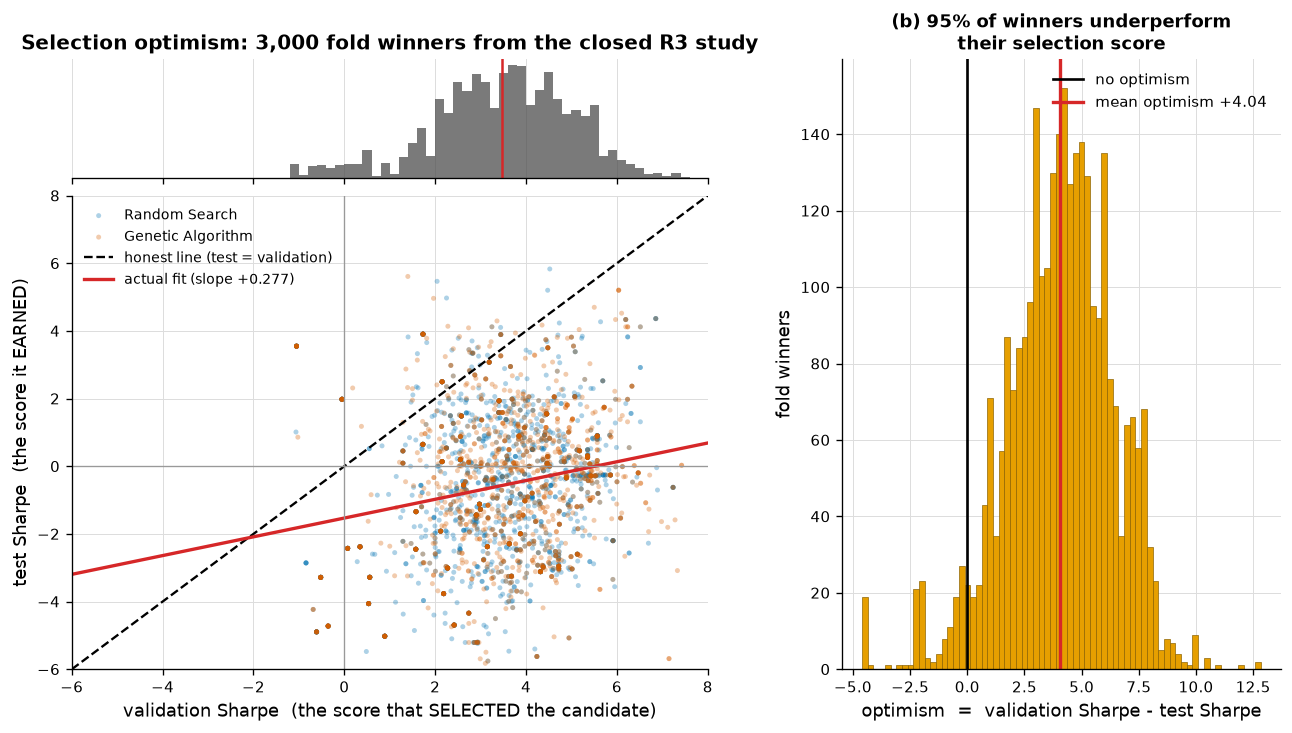

In [7]:
# --- I02: the selection-optimism scatter -------------------------------------
fig = plt.figure(figsize=(13.0, 6.6))
gs = fig.add_gridspec(
    2, 2, width_ratios=[1.45, 1.0], height_ratios=[1, 4], hspace=0.06, wspace=0.25
)

axS = fig.add_subplot(gs[1, 0])
axT = fig.add_subplot(gs[0, 0], sharex=axS)
lim = (-6, 8)
for engine in ENGINES:
    m = W.filter(pl.col("engine") == engine)
    axS.scatter(
        m["val_sharpe"].to_numpy(),
        m["test_sharpe"].to_numpy(),
        s=9,
        alpha=0.32,
        color=ENGINE_COLOR[engine],
        label=ENGINE_LABEL[engine],
        edgecolors="none",
    )
axS.plot(lim, lim, color="black", lw=1.4, ls="--", label="honest line (test = validation)")
xs = np.linspace(*lim, 50)
axS.plot(
    xs, intercept + slope * xs, color="#D62728", lw=2.0, label=f"actual fit (slope {slope:+.3f})"
)
axS.axhline(0, color="#999999", lw=0.8)
axS.axvline(0, color="#999999", lw=0.8)
axS.set_xlim(*lim)
axS.set_ylim(*lim)
axS.set_xlabel("validation Sharpe  (the score that SELECTED the candidate)")
axS.set_ylabel("test Sharpe  (the score it EARNED)")
axS.legend(fontsize=8.5, loc="upper left")

axT.hist(val, bins=70, range=lim, color="#4D4D4D", alpha=0.75)
axT.axvline(float(val.mean()), color="#D62728", lw=1.5)
axT.set_yticks([])
axT.tick_params(labelbottom=False)
axT.set_title("Selection optimism: 3,000 fold winners from the closed R3 study", fontsize=12)
for s in ("top", "right", "left"):
    axT.spines[s].set_visible(False)

axG = fig.add_subplot(gs[:, 1])
axG.hist(gap, bins=70, color="#E69F00", edgecolor="#8A6100", linewidth=0.4)
axG.axvline(0, color="black", lw=1.6, label="no optimism")
axG.axvline(float(gap.mean()), color="#D62728", lw=2.0, label=f"mean optimism {gap.mean():+.2f}")
axG.set_xlabel("optimism  =  validation Sharpe - test Sharpe")
axG.set_ylabel("fold winners")
axG.set_title(
    f"(b) {100 * (gap > 0).mean():.0f}% of winners underperform\ntheir selection score", fontsize=11
)
axG.legend(fontsize=9)

show(
    fig,
    "i02_selection_optimism",
    caption="Validation versus test Sharpe for every fold winner in the R3 study. The fitted slope "
    "is far below the honest diagonal, and the optimism distribution is centred well above "
    "zero.",
)

**Interpretation (4.1).** This is the most important figure in the notebook, and it says three things.

**The validation score is severely optimistic.** The average selected candidate arrives at its test
slice having lost the great majority of the Sharpe that earned it selection. That gap is not a small
correction to be mentioned in a footnote; it is comparable in size to the entire signal being claimed.

**The optimism is systematic, not random.** If selection were unbiased, the optimism histogram in
panel (b) would be centred on zero and roughly half the winners would beat their validation score.
Instead the distribution is shifted decisively to the right. This is the classic **winner's curse**:
selecting the maximum of many noisy estimates guarantees that the selected estimate contains an
upward error, and re-measuring it on fresh data removes that error. Nothing was implemented
incorrectly - this is what selection *does*, and it happens even when every guarantee from notebooks
`02` and `03` holds.

**A high validation score buys very little.** The fitted slope of test on validation is roughly
`0.28` against an honest value of `1.0`: about three-quarters of any validation advantage evaporates,
and the fit explains only a few percent of the variance in test outcomes. In practical terms, learning
that a candidate scored a validation Sharpe of 4 rather than 2 raises the expectation of its test
Sharpe by roughly half a point - while the residual scatter around that expectation spans several
points in both directions. The signal exists; it is simply swamped.

This is why a validation-selected result must *never* be reported as a performance estimate, and why
the entire fold-winner architecture exists: the test slice is scored once, after freezing, precisely
so that there is an unbiased number to report at all.

The practical corollary for anyone reading a backtest - in this thesis or elsewhere - is blunt. If a
reported Sharpe comes from the same data that chose the parameters, the correct prior is that most of
it will not survive contact with new data.

## 5. Where does the optimism live?

**Analytical question.** Is the optimism concentrated in particular families, or in particular regions
of the validation-score range? **Method.** We decompose the gap by family and by engine, and then
compute a **calibration curve**: bin the winners by their validation Sharpe and, within each bin,
report the mean test Sharpe actually achieved.

**Interpretation.** The calibration curve is the practically useful object. It answers the question a
researcher actually faces: *given that my search produced a validation Sharpe of X, what should I
expect?*

In [8]:
BY_FAMILY = (
    W.group_by("family", "engine")
    .agg(
        pl.len().alias("n_winners"),
        pl.col("val_sharpe").mean().alias("mean_val"),
        pl.col("test_sharpe").mean().alias("mean_test"),
        (pl.col("val_sharpe") - pl.col("test_sharpe")).mean().alias("mean_optimism"),
        (pl.col("test_sharpe") > 0).mean().alias("share_test_positive"),
    )
    .sort("family", "engine")
)
save_table(
    BY_FAMILY,
    "t03_optimism_by_family",
    ctx,
    caption="Selection optimism decomposed by strategy family and search engine.",
)
display(BY_FAMILY)

# --- Calibration: what does a given validation score actually deliver? -------
EDGES = np.array([-np.inf, -1, 0, 0.5, 1, 1.5, 2, 3, np.inf])
LBL = ["< -1", "-1 .. 0", "0 .. 0.5", "0.5 .. 1", "1 .. 1.5", "1.5 .. 2", "2 .. 3", "> 3"]
idx = np.digitize(val, EDGES[1:-1], right=False)
cal_rows = []
for b in range(len(LBL)):
    sel = idx == b
    if sel.sum() < 5:
        continue
    cal_rows.append(
        {
            "val_sharpe_bin": LBL[b],
            "n": int(sel.sum()),
            "mean_val": float(val[sel].mean()),
            "mean_test": float(tst[sel].mean()),
            "median_test": float(np.median(tst[sel])),
            "share_test_positive": float((tst[sel] > 0).mean()),
            "shrinkage": float(val[sel].mean() - tst[sel].mean()),
        }
    )
CAL = pl.DataFrame(cal_rows)
save_table(
    CAL,
    "t04_validation_calibration",
    ctx,
    caption="Mean test Sharpe achieved by fold winners, binned by the validation Sharpe that "
    "selected them.",
)
display(CAL)

family,engine,n_winners,mean_val,mean_test,mean_optimism,share_test_positive
str,str,u32,f64,f64,f64,f64
"""BTC_ETH_confirmation""","""genetic_algorithm""",300,3.959571,-0.408802,4.368373,0.436667
"""BTC_ETH_confirmation""","""random_search""",300,3.817185,-0.573206,4.390391,0.396667
"""breakout""","""genetic_algorithm""",300,1.711142,-1.25523,2.966372,0.36
"""breakout""","""random_search""",300,1.687798,-1.310698,2.998495,0.35
"""funding""","""genetic_algorithm""",300,4.47273,-0.15437,4.6271,0.456667
"""funding""","""random_search""",300,4.301936,-0.270268,4.572204,0.413333
"""mean_reversion""","""genetic_algorithm""",300,3.968331,-0.372872,4.341203,0.453333
"""mean_reversion""","""random_search""",300,3.854384,-0.551555,4.405939,0.396667
"""volatility_breakout""","""genetic_algorithm""",300,3.52903,-0.428012,3.957043,0.423333


val_sharpe_bin,n,mean_val,mean_test,median_test,share_test_positive,shrinkage
str,i64,f64,f64,f64,f64,f64
"""< -1""",21,-1.051295,3.300697,3.549628,1.0,-4.351992
"""-1 .. 0""",79,-0.409449,-2.583281,-3.283561,0.253165,2.173832
"""0 .. 0.5""",43,0.217605,-2.292466,-2.427046,0.046512,2.510071
"""0.5 .. 1""",70,0.670348,-3.661451,-4.05979,0.042857,4.331799
"""1 .. 1.5""",49,1.319212,-0.464846,0.09082,0.530612,1.784057
"""1.5 .. 2""",157,1.723528,-0.284803,-0.810924,0.420382,2.008331
"""2 .. 3""",674,2.54644,-0.748379,-0.723055,0.382789,3.294819
"""> 3""",1907,4.383954,-0.337072,-0.259127,0.442056,4.721026


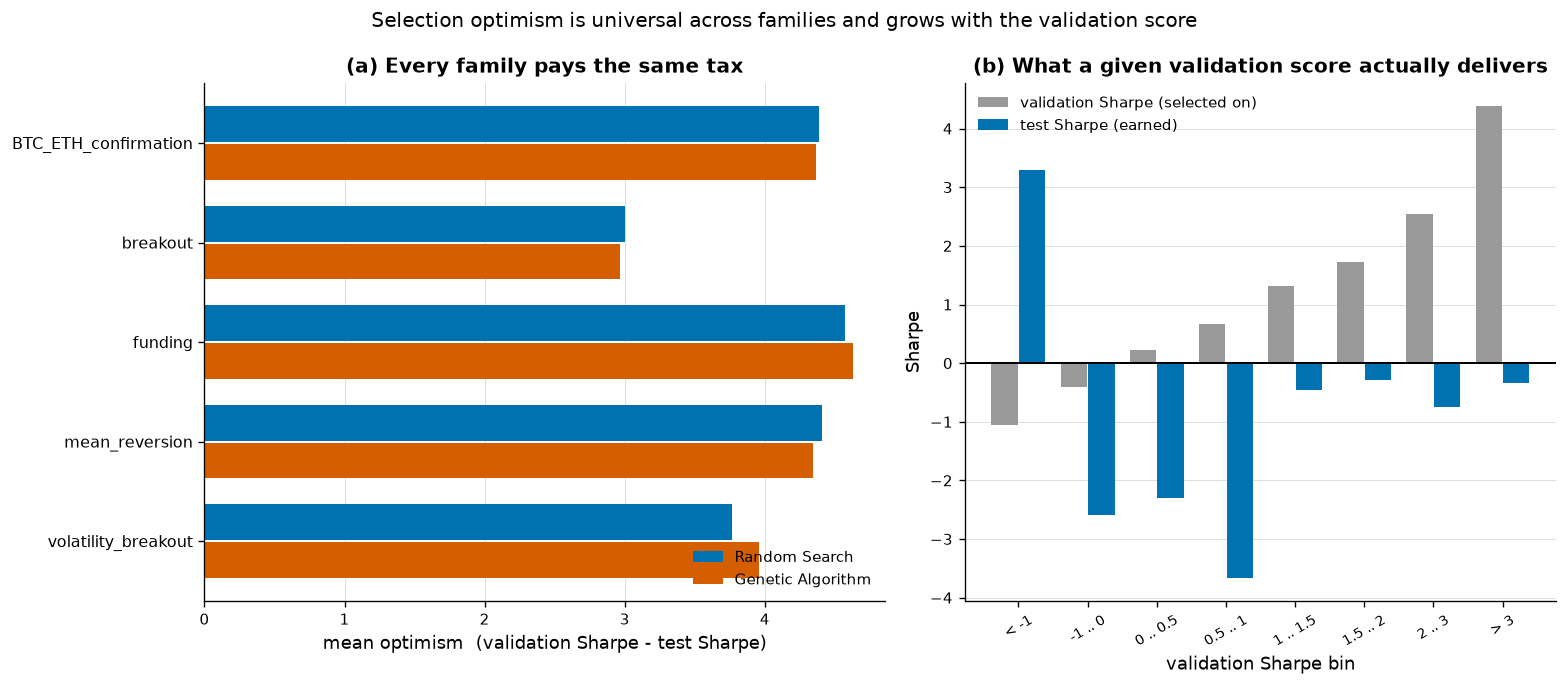

In [9]:
# --- I03: optimism by family and the calibration curve -----------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.2, 5.8), gridspec_kw={"width_ratios": [1.15, 1.0]})

fams = sorted(W["family"].unique().to_list())
ypos = np.arange(len(fams))
for k, engine in enumerate(ENGINES):
    vals = []
    for f in fams:
        s = BY_FAMILY.filter((pl.col("family") == f) & (pl.col("engine") == engine))
        vals.append(float(s["mean_optimism"][0]) if s.height else np.nan)
    axA.barh(
        ypos + (k - 0.5) * 0.38,
        vals,
        height=0.36,
        color=ENGINE_COLOR[engine],
        label=ENGINE_LABEL[engine],
    )
axA.axvline(0, color="black", lw=1.2)
axA.set_yticks(ypos)
axA.set_yticklabels(fams, fontsize=9.5)
axA.invert_yaxis()
axA.set_xlabel("mean optimism  (validation Sharpe - test Sharpe)")
axA.set_title("(a) Every family pays the same tax")
axA.legend(fontsize=9, loc="lower right")
axA.grid(axis="y", visible=False)

xb = np.arange(CAL.height)
axB.bar(
    xb - 0.2,
    CAL["mean_val"].to_numpy(),
    width=0.38,
    color="#999999",
    label="validation Sharpe (selected on)",
)
axB.bar(
    xb + 0.2, CAL["mean_test"].to_numpy(), width=0.38, color="#0072B2", label="test Sharpe (earned)"
)
axB.axhline(0, color="black", lw=1.2)
axB.set_xticks(xb)
axB.set_xticklabels(CAL["val_sharpe_bin"].to_list(), rotation=30, fontsize=8.5)
axB.set_xlabel("validation Sharpe bin")
axB.set_ylabel("Sharpe")
axB.set_title("(b) What a given validation score actually delivers")
axB.legend(fontsize=9)
axB.grid(axis="x", visible=False)

fig.suptitle(
    "Selection optimism is universal across families and grows with the validation score",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "i03_optimism_structure",
    caption="Mean selection optimism by family and engine (a), and the calibration of validation "
    "scores against realised test Sharpe (b).",
)

**Interpretation (5.1).** Panel (a) shows that the optimism is not a property of one badly behaved
family - it is a tax paid by all of them, and paid at a similar rate by both engines. That uniformity
is itself the evidence that the cause is structural: had it been driven by a particular strategy's
quirks, it would vary between families.

Panel (b) is the calibration curve, and its message is stronger than a story about shrinkage growing
with the score. **The realised test Sharpe is essentially flat across every populated validation
bin.** Winners selected at a validation Sharpe between 1 and 1.5 earn, on average, roughly what
winners selected above 3 earn - a small negative number in both cases. The grey bars climb steadily
from left to right; the blue bars do not move.

That flatness is the practical content of the shallow regression slope in Section 4. Knowing a
candidate's validation score tells you very little about what it will earn. The shrinkage column is
consequently large wherever the validation score was large, not because high scorers are punished, but
because *everyone lands in the same place* and only the starting point differed.

Two smaller bins deserve an honest caveat rather than a silent omission. The `< -1` bin contains
only twenty-one winners and shows a strongly *positive* mean test Sharpe; with that sample size, and
given that those cases arise in folds where every candidate scored badly, this is noise rather than
evidence that bad validation scores predict good outcomes. The bins between 0 and 1 are similarly
thin. The bulk of the evidence - some 2,500 of the 3,000 winners - sits in the two right-hand bins,
and it is flat.

The methodological consequence is that **an impressive validation number should not raise confidence
at all.** Any workflow that reports its best validation result as a headline is not reporting a
strategy; it is reporting the size of its own search.

## 6. Random Search versus the Genetic Algorithm, on a verified equal budget

**Analytical question.** Does an evolutionary search find better strategies than blind sampling, when
both are given exactly the same number of evaluations on exactly the same space and folds?

**Method.** The budget caps **unique, valid, non-cached objective evaluations**. Invalid proposals,
duplicates and cache hits consume nothing - which is what stops the GA's elitism from buying extra
evaluations by rediscovering candidates it already knows. Parity is asserted **inside every outer
fold**, because a matching run-level total can still hide an unevenly searched fold. We audit that
claim directly from the stored counters, then compare outcomes.

**Interpretation.** Read this section together with Section 3: the spaces are small, so this is a test
of whether evolution helps in a regime where there is little left to discover.

In [10]:
parity_rows = []
for family in FAMILIES:
    manifest = json.loads((STUDY_ROOT / family / "study_manifest.json").read_text(encoding="utf-8"))
    for unit in manifest["units"].values():
        run_dir = Path(str(unit["run_dir"]).replace("\\", "/"))
        spath = run_dir / "comparison_summary.json"
        if not spath.exists():
            continue
        s = json.loads(spath.read_text(encoding="utf-8"))
        bp = s.get("budget_parity", {})
        for engine, rec in bp.get("per_engine", {}).items():
            per_fold = rec.get("per_fold", {})
            consumed = [int(v["consumed"]) for v in per_fold.values()]
            parity_rows.append(
                {
                    "family": family,
                    "symbol": unit["symbol"],
                    "seed": int(unit["seed"]),
                    "engine": engine,
                    "budget_per_fold": int(rec["budget_per_fold"]),
                    "folds_searched": int(rec["n_folds_searched"]),
                    "total_unique_evals": int(rec["total_unique_evaluations"]),
                    "min_consumed_in_a_fold": min(consumed) if consumed else None,
                    "max_consumed_in_a_fold": max(consumed) if consumed else None,
                    "reached_target_everywhere": bool(rec["reached_target_in_every_fold"]),
                    "duplicates_rejected": sum(
                        int(v.get("duplicate", 0)) for v in per_fold.values()
                    ),
                    "proposals_made": sum(int(v.get("proposed", 0)) for v in per_fold.values()),
                }
            )
PARITY = pl.DataFrame(parity_rows)
AUDIT = (
    PARITY.group_by("engine")
    .agg(
        pl.len().alias("units"),
        pl.col("total_unique_evals").sum().alias("total_unique_evaluations"),
        pl.col("reached_target_everywhere").all().alias("target_met_in_every_fold"),
        pl.col("min_consumed_in_a_fold").min().alias("worst_fold_consumption"),
        pl.col("proposals_made").sum().alias("proposals_made"),
        pl.col("duplicates_rejected").sum().alias("duplicates_rejected"),
    )
    .sort("engine")
)
save_table(
    AUDIT,
    "t05_budget_parity_audit",
    ctx,
    caption="Per-engine budget audit aggregated over every unit and fold of the R3 study.",
)
display(AUDIT)

totals = AUDIT["total_unique_evaluations"].to_list()
print(f"\nS4 identical total evaluations per engine : {totals[0] == totals[1]} ({totals})")
print(
    f"S4 target reached in EVERY fold           : {bool(AUDIT['target_met_in_every_fold'].all())}"
)
for r in AUDIT.iter_rows(named=True):
    waste = 100 * r["duplicates_rejected"] / max(1, r["proposals_made"])
    print(
        f"   {ENGINE_LABEL[r['engine']]:<18}: {r['proposals_made']:,} proposals -> "
        f"{r['duplicates_rejected']:,} duplicates rejected ({waste:.0f}%), consuming no budget"
    )

engine,units,total_unique_evaluations,target_met_in_every_fold,worst_fold_consumption,proposals_made,duplicates_rejected
str,u32,i64,bool,i64,i64,i64
"""genetic_algorithm""",100,150000,true,100,356382,84244
"""random_search""",100,150000,true,100,237769,87769



S4 identical total evaluations per engine : True ([150000, 150000])
S4 target reached in EVERY fold           : True
   Genetic Algorithm : 356,382 proposals -> 84,244 duplicates rejected (24%), consuming no budget
   Random Search     : 237,769 proposals -> 87,769 duplicates rejected (37%), consuming no budget


In [11]:
# --- Paired comparison, using the study's own inference layer ---------------
paired_rows = []
for family in FAMILIES:
    a = json.loads((STUDY_ROOT / family / "multi_seed_analysis.json").read_text(encoding="utf-8"))
    comb = a["paired_rs_vs_ga"]["combined"]
    paired_rows.append(
        {
            "family": family,
            "n_units": int(comb["n_units"]),
            "mean_ga_minus_rs": float(comb["mean_difference"]),
            "ci_low": float(comb["ci_low"]),
            "ci_high": float(comb["ci_high"]),
            "cohens_dz": float(comb["effect_size_cohens_dz"]),
            "favouring_ga": int(comb["n_units_favouring_ga"]),
            "favouring_rs": int(comb["n_units_favouring_rs"]),
            "ci_excludes_zero": bool(comb["ci_excludes_zero"]),
        }
    )
PAIRED = pl.DataFrame(paired_rows).sort("family")
save_table(
    PAIRED,
    "t06_rs_vs_ga_paired",
    ctx,
    caption="Paired GA - RS comparison per family, using symbol x fold as the unit of "
    "inference with seeds averaged inside each cell.",
)
display(PAIRED)
UNIT_OF_INF = json.loads(
    (STUDY_ROOT / FAMILIES[0] / "multi_seed_analysis.json").read_text(encoding="utf-8")
)["paired_rs_vs_ga"]["unit_of_inference"]
print(f"\nUnit of inference : {UNIT_OF_INF}")
print(
    f"Families whose CI excludes zero : {int(PAIRED['ci_excludes_zero'].sum())} / {PAIRED.height}"
)

family,n_units,mean_ga_minus_rs,ci_low,ci_high,cohens_dz,favouring_ga,favouring_rs,ci_excludes_zero
str,i64,f64,f64,f64,f64,i64,i64,bool
"""BTC_ETH_confirmation""",15,0.164404,-0.084405,0.413213,0.365918,11,4,false
"""breakout""",15,0.055468,-0.034065,0.145,0.343082,9,3,false
"""funding""",15,0.115898,-0.226968,0.458764,0.187193,9,6,false
"""mean_reversion""",15,0.178683,0.011852,0.345515,0.593122,11,4,true
"""volatility_breakout""",15,-0.071902,-0.365766,0.221962,-0.135498,7,8,false



Unit of inference : calendar fold (seeds averaged, then assets averaged)
Families whose CI excludes zero : 1 / 5


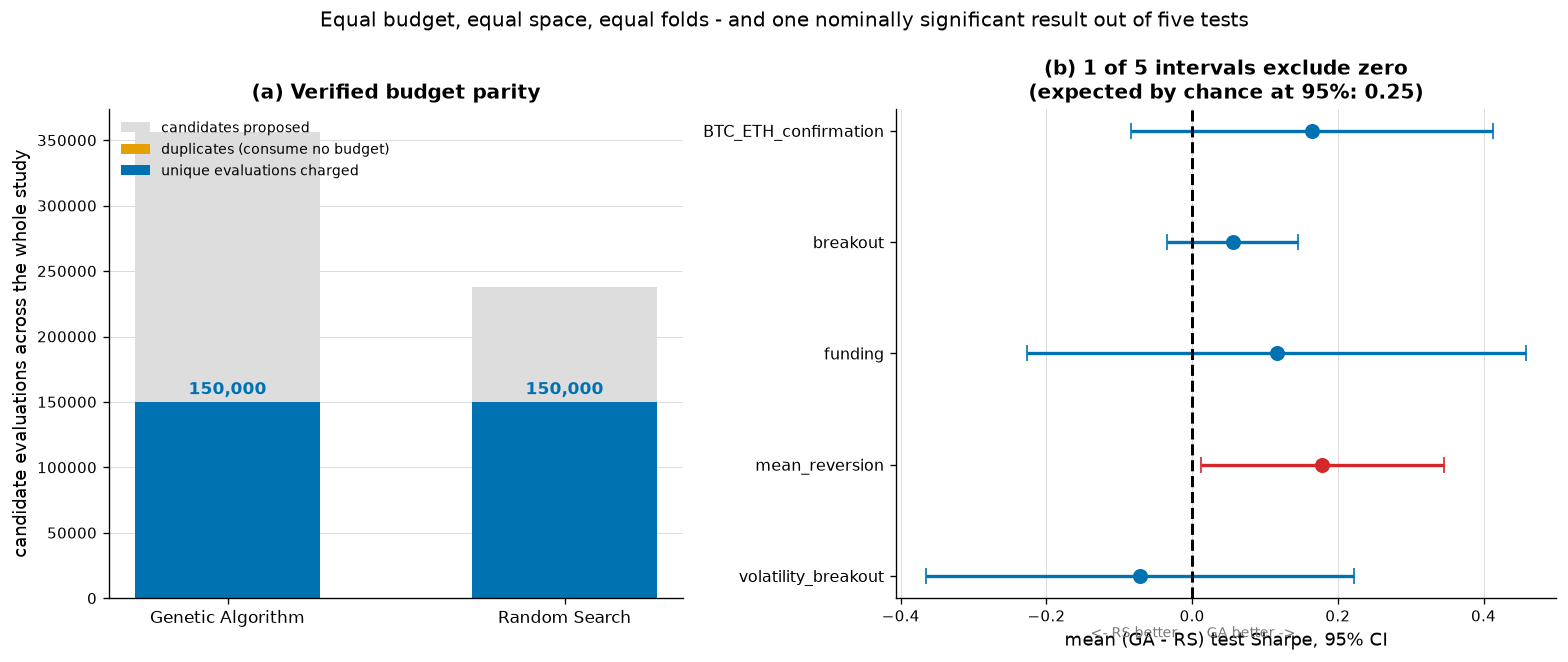

In [12]:
# --- I04: budget parity and the paired comparison ----------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.2, 5.6), gridspec_kw={"width_ratios": [1.0, 1.15]})

engines = AUDIT["engine"].to_list()
prop = AUDIT["proposals_made"].to_numpy()
dup = AUDIT["duplicates_rejected"].to_numpy()
used = AUDIT["total_unique_evaluations"].to_numpy()
xp = np.arange(len(engines))
axA.bar(xp, prop, color="#DDDDDD", width=0.55, label="candidates proposed")
axA.bar(xp, dup, color="#E69F00", width=0.55, label="duplicates (consume no budget)")
axA.bar(xp, used, color="#0072B2", width=0.55, label="unique evaluations charged")
for i, u in enumerate(used):
    axA.text(i, u * 1.04, f"{u:,}", ha="center", fontsize=10, fontweight="bold", color="#0072B2")
axA.set_xticks(xp)
axA.set_xticklabels([ENGINE_LABEL[e] for e in engines], fontsize=10)
axA.set_ylabel("candidate evaluations across the whole study")
axA.set_title("(a) Verified budget parity")
axA.legend(fontsize=8.5, loc="upper left")
axA.grid(axis="x", visible=False)

yy = np.arange(PAIRED.height)
mid = PAIRED["mean_ga_minus_rs"].to_numpy()
lo = PAIRED["ci_low"].to_numpy()
hi = PAIRED["ci_high"].to_numpy()
excl = PAIRED["ci_excludes_zero"].to_list()
cols = ["#D62728" if e else "#0072B2" for e in excl]
for i in range(PAIRED.height):
    axB.errorbar(
        mid[i],
        yy[i],
        xerr=[[mid[i] - lo[i]], [hi[i] - mid[i]]],
        fmt="o",
        ms=8,
        lw=2.0,
        color=cols[i],
        ecolor=cols[i],
        capsize=5,
    )
axB.axvline(0, color="black", lw=1.8, ls="--")
axB.set_yticks(yy)
axB.set_yticklabels(PAIRED["family"].to_list(), fontsize=9.5)
axB.invert_yaxis()
axB.set_xlabel("mean (GA - RS) test Sharpe, 95% CI")
n_excl = int(PAIRED["ci_excludes_zero"].sum())
axB.set_title(
    f"(b) {n_excl} of {PAIRED.height} intervals exclude zero\n"
    f"(expected by chance at 95%: {0.05 * PAIRED.height:.2f})"
)
axB.text(0.02, PAIRED.height - 0.45, "GA better ->", fontsize=8.5, color="#777777", ha="left")
axB.text(-0.02, PAIRED.height - 0.45, "<- RS better", fontsize=8.5, color="#777777", ha="right")
axB.grid(axis="y", visible=False)

fig.suptitle(
    "Equal budget, equal space, equal folds - and one nominally significant result "
    "out of five tests",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "i04_rs_vs_ga",
    caption="Verified budget parity across the study (a) and the paired GA - RS comparison per "
    "family with 95% confidence intervals (b).",
)

**Interpretation (6.1).** Parity holds exactly: both engines consumed the identical number of unique
evaluations in every fold of every unit. The proposal counters in panel (a) also make the accounting
visible - a large share of what both engines propose is a duplicate of something already scored, and
those cost nothing. That rule is what makes the comparison fair, because an engine with memory (the
GA's elitism) would otherwise be charged repeatedly for re-proposing its own champions and would
appear to be handicapped.

The paired comparison in panel (b) requires the kind of care that separates a finding from an
artefact. **Four of the five intervals straddle zero. One - `mean_reversion` - excludes it**, with a
mean advantage to the GA and a moderate effect size.

It would be easy, and wrong, to report that as "the GA beats Random Search on mean reversion". Five
independent tests were run at the 95% level, so the expected number of intervals excluding zero *under
the null hypothesis that no engine difference exists anywhere* is 0.25 - and observing one is entirely
unremarkable. The probability of at least one false positive across five such tests is about 23%.
Applying even the crudest multiple-testing correction, a Bonferroni threshold of 0.05/5 = 0.01, would
require a far wider interval than the one observed, and `mean_reversion`'s lower bound sits at 0.012,
barely clear of zero.

The signature of a real effect would be **consistency**: the same direction, of comparable magnitude,
across families. What the data show instead is four point estimates mildly favouring the GA, one
mildly favouring Random Search, and confidence intervals that all overlap each other substantially.

The defensible conclusion is therefore: **no reliable evidence of an engine advantage**, with the
`mean_reversion` result flagged as a nominally significant finding that does not survive correction
for the five tests performed. Random Search remains the default baseline, and the Genetic Algorithm is
retained only as an equal-budget comparator. This is precisely the kind of result that motivates the
study-level multiple-testing analysis in notebook `05` - the temptation to report the one interesting
cell out of five is exactly what that machinery exists to resist.

## 7. Seed instability: how much of a result is the seed?

**Analytical question.** Ten runs differing only in their random seed search the same space, on the
same data, with the same budget. How much does the answer move? **Method.** For each family and engine
we compute the spread of test Sharpe across seeds within a fixed `(symbol, fold)` cell, and compare it
against the spread across folds - the study's `seed_to_fold_sd_ratio`.

**Interpretation.** This ratio is the single most useful sanity number in the project. It says how
much of an observed result is a property of the market versus a property of the random number
generator.

In [13]:
stab_rows = []
for family in FAMILIES:
    a = json.loads((STUDY_ROOT / family / "multi_seed_analysis.json").read_text(encoding="utf-8"))
    vd = a["variance_decomposition"]
    ratios = vd.get("seed_to_fold_sd_ratio", {}).get("values", {})
    for engine in ENGINES:
        rec = vd.get(engine, {})
        stab_rows.append(
            {
                "family": family,
                "engine": engine,
                "seed_sd": float(
                    rec.get("seed_variability", {}).get("mean_sd_within_symbol_fold", float("nan"))
                ),
                "fold_sd": float(
                    rec.get("fold_variability", {}).get("mean_sd_within_run", float("nan"))
                ),
                "seed_to_fold_sd_ratio": float(ratios.get(engine, float("nan"))),
            }
        )
STAB = pl.DataFrame(stab_rows)
save_table(
    STAB,
    "t07_seed_instability",
    ctx,
    caption="Variance decomposition: dispersion attributable to the search seed versus to the "
    "market period.",
)
display(STAB)

# Direct measurement from the winners frame, as a cross-check.
CELL = (
    W.group_by("family", "engine", "symbol", "fold")
    .agg(
        pl.col("test_sharpe").std().alias("sd_across_seeds"),
        pl.col("test_sharpe").mean().alias("mean_across_seeds"),
        pl.len().alias("n_seeds"),
    )
    .filter(pl.col("n_seeds") > 1)
)
print(f"\nCells (family x engine x symbol x fold) : {CELL.height}")
print(
    f"Median SD across seeds within a cell    : "
    f"{float(CELL['sd_across_seeds'].median()):.3f} Sharpe"
)
print(
    f"SD of the cell means across folds       : {float(CELL['mean_across_seeds'].std()):.3f} Sharpe"
)

family,engine,seed_sd,fold_sd,seed_to_fold_sd_ratio
str,str,f64,f64,f64
"""BTC_ETH_confirmation""","""random_search""",1.501275,2.27304,0.925
"""BTC_ETH_confirmation""","""genetic_algorithm""",1.49834,2.14982,0.9631
"""breakout""","""random_search""",0.375781,2.582232,0.1507
"""breakout""","""genetic_algorithm""",0.135872,2.614121,0.0531
"""funding""","""random_search""",1.562318,1.980897,1.2923
"""funding""","""genetic_algorithm""",1.437077,2.060226,1.0148
"""mean_reversion""","""random_search""",0.869631,1.604964,0.6562
"""mean_reversion""","""genetic_algorithm""",0.754115,1.63391,0.5421
"""volatility_breakout""","""random_search""",1.276448,1.972316,0.8876



Cells (family x engine x symbol x fold) : 300
Median SD across seeds within a cell    : 1.062 Sharpe
SD of the cell means across folds       : 1.721 Sharpe


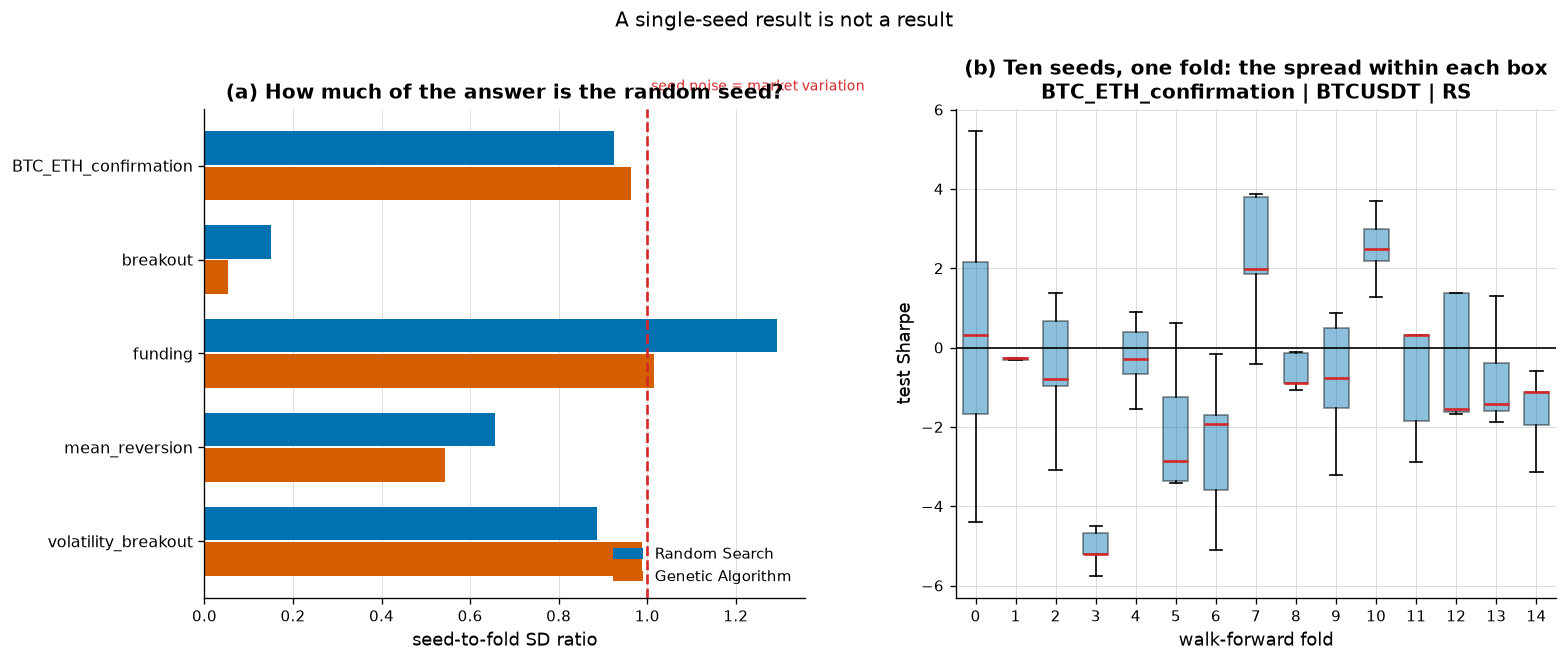

In [14]:
# --- I05: seed instability ----------------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.2, 5.6))

fam_order = sorted(STAB["family"].unique().to_list())
yy = np.arange(len(fam_order))
for k, engine in enumerate(ENGINES):
    r = [
        float(
            STAB.filter((pl.col("family") == f) & (pl.col("engine") == engine))[
                "seed_to_fold_sd_ratio"
            ][0]
        )
        for f in fam_order
    ]
    axA.barh(
        yy + (k - 0.5) * 0.38,
        r,
        height=0.36,
        color=ENGINE_COLOR[engine],
        label=ENGINE_LABEL[engine],
    )
axA.axvline(1.0, color="#D62728", lw=1.6, ls="--")
axA.text(1.0, -0.8, " seed noise = market variation", fontsize=8.5, color="#D62728")
axA.set_yticks(yy)
axA.set_yticklabels(fam_order, fontsize=9.5)
axA.invert_yaxis()
axA.set_xlabel("seed-to-fold SD ratio")
axA.set_title("(a) How much of the answer is the random seed?")
axA.legend(fontsize=9, loc="lower right")
axA.grid(axis="y", visible=False)

sample = W.filter(
    (pl.col("family") == fam_order[0])
    & (pl.col("engine") == "random_search")
    & (pl.col("symbol") == "BTCUSDT")
)
folds = sorted(sample["fold"].unique().to_list())
data = [sample.filter(pl.col("fold") == f)["test_sharpe"].to_numpy() for f in folds]
bp = axB.boxplot(data, positions=folds, widths=0.62, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#0072B2")
    patch.set_alpha(0.45)
for med in bp["medians"]:
    med.set_color("#D62728")
    med.set_linewidth(1.6)
axB.axhline(0, color="black", lw=1.0)
axB.set_xlabel("walk-forward fold")
axB.set_ylabel("test Sharpe")
axB.set_title(f"(b) Ten seeds, one fold: the spread within each box\n{fam_order[0]} | BTCUSDT | RS")

fig.suptitle("A single-seed result is not a result", fontsize=12)
fig.tight_layout()
show(
    fig,
    "i05_seed_instability",
    caption="Seed-to-fold standard-deviation ratio by family and engine (a) and the per-fold spread "
    "of test Sharpe across ten seeds for one family (b).",
)

**Interpretation (7.1).** Panel (b) makes the abstract point concrete: within a single fold - one
fixed market period, one asset, one family - simply changing the search seed moves the test Sharpe
across a visibly wide range, frequently spanning zero. The candidate that "wins" a fold is therefore
partly an accident of which parameterisations happened to be sampled first.

The ratio in panel (a) quantifies this against the natural benchmark, and the spread across families
is stark. `breakout` sits far below one - unsurprisingly, since its space is nearly exhausted, so
every seed converges on much the same candidates. But `funding` **exceeds one for both engines**, and
`BTC_ETH_confirmation` and `volatility_breakout` sit close to it. For those families, re-running the
search with a different random seed moves the result *as much as, or more than, moving to an entirely
different market period.*

That is a remarkable statement about what a single-seed backtest of such a family would be measuring:
mostly its own random number generator. It makes **multiple seeds mandatory rather than optional** -
any single-seed claim in this repository is provisional by construction, and the ten-seed protocol
exists precisely because early single-seed pilots produced apparent GA advantages that did not survive
replication.

This is also why the unit of statistical inference is `symbol x fold` with seeds **averaged inside**
each cell, rather than treating all 300 seed-runs as independent observations. Seeds share one price
history; counting them as independent would shrink every confidence interval by roughly the square
root of ten and manufacture significance out of nothing.

## 8. What does the search converge to?

**Analytical question.** How quickly does each engine find its fold's best validation candidate, and
what does the shape of that curve reveal? **Method.** Each run records, per fold, the best fitness
found so far after each unique evaluation. We average these monotone traces across units.

**Interpretation.** A curve that plateaus almost immediately is not evidence of an efficient
optimiser; it is evidence that the space contained little to find.

In [15]:
conv = {e: [] for e in ENGINES}
for family in FAMILIES:
    manifest = json.loads((STUDY_ROOT / family / "study_manifest.json").read_text(encoding="utf-8"))
    for unit in manifest["units"].values():
        run_dir = Path(str(unit["run_dir"]).replace("\\", "/"))
        for engine in ENGINES:
            p = run_dir / f"{engine}_convergence.json"
            if not p.exists():
                continue
            data = json.loads(p.read_text(encoding="utf-8"))
            for trace in data.get("per_fold", {}).values():
                arr = np.asarray(trace, dtype=float)
                if arr.size:
                    conv[engine].append(arr)

MAXLEN = max(max((a.size for a in conv[e]), default=0) for e in ENGINES)
curves = {}
for engine in ENGINES:
    padded = np.full((len(conv[engine]), MAXLEN), np.nan)
    for i, a in enumerate(conv[engine]):
        padded[i, : a.size] = a
        padded[i, a.size :] = a[-1]
    curves[engine] = padded

conv_rows = []
for engine in ENGINES:
    c = curves[engine]
    final = np.nanmean(c[:, -1])
    for frac in (0.1, 0.25, 0.5, 1.0):
        k = max(1, int(MAXLEN * frac)) - 1
        conv_rows.append(
            {
                "engine": engine,
                "budget_fraction": frac,
                "evaluations": k + 1,
                "mean_best_fitness": float(np.nanmean(c[:, k])),
                "pct_of_final": float(100 * np.nanmean(c[:, k]) / final) if final else float("nan"),
            }
        )
CONV = pl.DataFrame(conv_rows)
save_table(
    CONV,
    "t08_convergence",
    ctx,
    caption="Mean best-so-far validation fitness at fractions of the evaluation budget.",
)
display(CONV)
print(f"\nConvergence traces averaged: { {e: len(conv[e]) for e in ENGINES} }")

engine,budget_fraction,evaluations,mean_best_fitness,pct_of_final
str,f64,i64,f64,f64
"""random_search""",0.1,94,2.002119,98.61108
"""random_search""",0.25,236,2.030318,100.0
"""random_search""",0.5,472,2.030318,100.0
"""random_search""",1.0,945,2.030318,100.0
"""genetic_algorithm""",0.1,94,2.047351,94.705149
"""genetic_algorithm""",0.25,236,2.156508,99.754441
"""genetic_algorithm""",0.5,472,2.160845,99.955098
"""genetic_algorithm""",1.0,945,2.161816,100.0



Convergence traces averaged: {'random_search': 1500, 'genetic_algorithm': 1500}


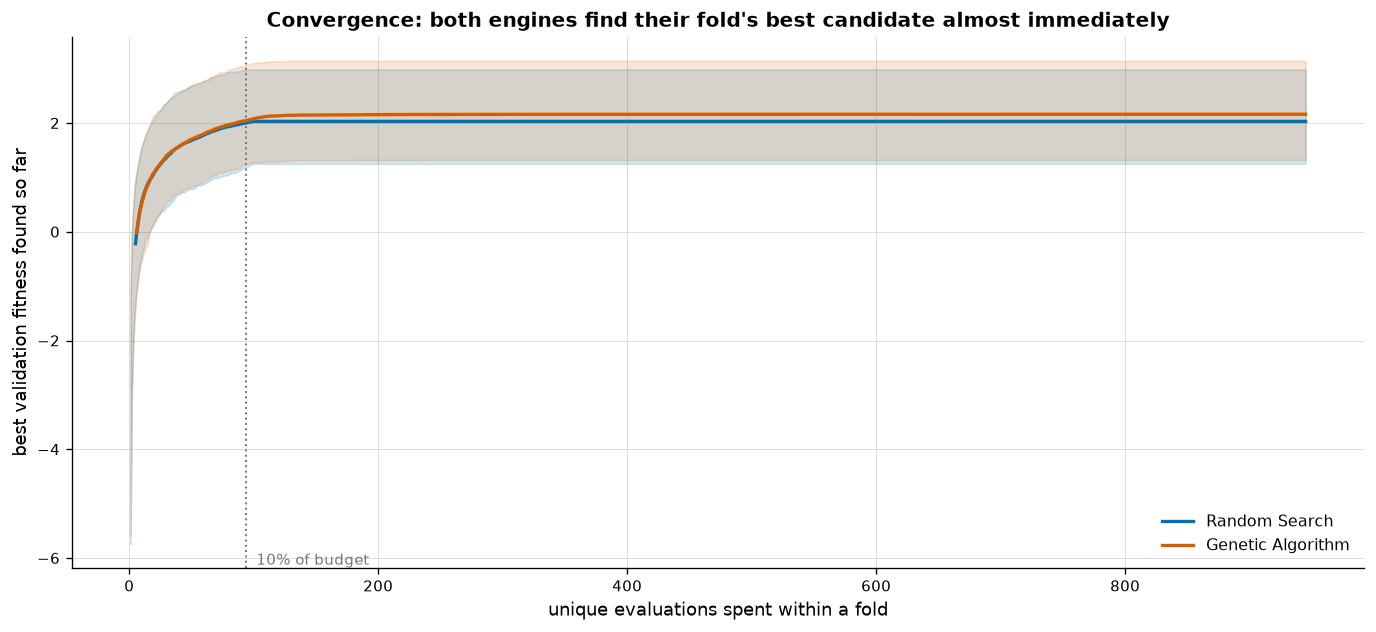

In [16]:
# --- I06: convergence ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.6, 5.4))
xs = np.arange(1, MAXLEN + 1)
for engine in ENGINES:
    c = curves[engine]
    mean = np.nanmean(c, axis=0)
    q1 = np.nanpercentile(c, 25, axis=0)
    q3 = np.nanpercentile(c, 75, axis=0)
    ax.plot(xs, mean, color=ENGINE_COLOR[engine], lw=2.0, label=ENGINE_LABEL[engine])
    ax.fill_between(xs, q1, q3, color=ENGINE_COLOR[engine], alpha=0.16)
half = max(1, MAXLEN // 10)
ax.axvline(half, color="#777777", lw=1.2, ls=":")
ax.text(half, ax.get_ylim()[0], "  10% of budget", fontsize=9, color="#777777", va="bottom")
ax.set_xlabel("unique evaluations spent within a fold")
ax.set_ylabel("best validation fitness found so far")
ax.set_title(
    "Convergence: both engines find their fold's best candidate almost immediately", fontsize=12
)
ax.legend(fontsize=9.5)
fig.tight_layout()
show(
    fig,
    "i06_convergence",
    caption="Mean best-so-far validation fitness against evaluations spent, with the interquartile "
    "band across all folds and units of the study.",
)

**Interpretation (8.1).** Both engines reach the overwhelming majority of their final best fitness
within the first tenth of the budget, and the two curves are close to indistinguishable thereafter.
Read naively, this looks like efficiency. Read together with Section 3, it is diagnostic of something
else: **the space is small enough that a good candidate is found almost immediately by chance**, and
the remaining ninety percent of the budget mostly rediscovers candidates already scored.

That reframes the negative RS-versus-GA result once more. The GA is not failing to climb a difficult
landscape; there is barely a landscape to climb. It also explains the duplicate counts in Section 6 -
both engines spend most of their proposals re-proposing known points.

The honest methodological lesson is that **budget should be set relative to the cardinality of the
space**, and that reporting "we evaluated N candidates" without stating the size of the space is
uninformative. That reasoning is what [ADR 0014](../docs/decisions/0014-r3-budget-bounded-by-search-space.md)
records.

## 9. Findings and implications

In [17]:
findings = [
    {
        "id": "S1",
        "finding": "Space cardinality differs by two orders of magnitude; the shared budget is bounded "
        "by the smallest space, so coverage ranges from near-exhaustive to ~1%",
        "evidence": f"t01: coverage {float(SPACE['coverage_pct'].min()):.1f}% .. "
        f"{float(SPACE['coverage_pct'].max()):.1f}%; ADR 0014",
        "implication": "The GA had ample room to win on the three large families and did not; only the "
        "breakout result carries a small-space caveat",
    },
    {
        "id": "S2",
        "finding": "Validation scores are severely optimistic estimates of test performance",
        "evidence": f"t02: mean validation {val.mean():+.2f} vs mean test {tst.mean():+.2f}; "
        f"{100 * (gap > 0).mean():.0f}% of winners underperform their selection score",
        "implication": "A validation-selected number is never reportable as performance",
    },
    {
        "id": "S3",
        "finding": f"Only about {100 * slope:.0f}% of a validation advantage transfers to the test slice",
        "evidence": f"i02: regression slope {slope:+.3f} against an honest 1.0, R^2 {r_val**2:.3f}",
        "implication": "Ranking candidates by validation Sharpe is mostly ranking them by noise",
    },
    {
        "id": "S4",
        "finding": "Realised test Sharpe is flat across validation bins; a higher selection score buys "
        "nothing",
        "evidence": "t04: mean test Sharpe is a small negative number in every well-populated bin, from "
        "'1 .. 1.5' through '> 3'",
        "implication": "An impressive validation result should not raise confidence at all",
    },
    {
        "id": "S5",
        "finding": "Budget parity is exact: both engines spent identical unique evaluations in every fold",
        "evidence": f"t05: {AUDIT['total_unique_evaluations'].to_list()} evaluations; "
        f"target met in every fold = {bool(AUDIT['target_met_in_every_fold'].all())}",
        "implication": "Any engine difference cannot be attributed to unequal search effort",
    },
    {
        "id": "S6",
        "finding": f"{int(PAIRED['ci_excludes_zero'].sum())} of {PAIRED.height} families has a CI "
        "excluding zero - consistent with chance across five tests, and inconsistent in "
        "direction across families",
        "evidence": f"t06: {PAIRED.filter(pl.col('ci_excludes_zero'))['family'].to_list()} nominally "
        f"significant; ~{0.05 * PAIRED.height:.2f} expected under the null",
        "implication": "No reliable engine advantage; Random Search remains the default and the GA an "
        "equal-budget comparator only",
    },
    {
        "id": "S7",
        "finding": "Seed noise rivals market variation on the large-space families",
        "evidence": f"t07: seed-to-fold SD ratio ranges "
        f"{float(STAB['seed_to_fold_sd_ratio'].min()):.2f} .. "
        f"{float(STAB['seed_to_fold_sd_ratio'].max()):.2f}; funding exceeds 1.0",
        "implication": "Multiple seeds are mandatory; the unit of inference is symbol x fold, not seed-run",
    },
    {
        "id": "S8",
        "finding": "Both engines converge within the first tenth of the budget",
        "evidence": "t08 / i06: mean best fitness reaches most of its final value early",
        "implication": "The remaining budget rediscovers known candidates; the space is the binding constraint",
    },
]
FINDINGS = pl.DataFrame(findings)
save_table(
    FINDINGS, "t09_search_findings", ctx, caption="Findings of the search and overfitting analysis."
)
display(FINDINGS)
print(f"\nArtifacts written under : {ctx.figures_dir} | {ctx.tables_dir}")
print(
    f"Evidence base           : {WINNERS.height:,} fold winners, {UNITS.height * len(FAMILIES) // len(FAMILIES)} units per family"
)
print("Holdout status          : not used here; opened once on 2026-08-13, reading withheld")

id,finding,evidence,implication
str,str,str,str
"""S1""","""Space cardinality differs by t…","""t01: coverage 1.1% .. 92.6%; A…","""The GA had ample room to win o…"
"""S2""","""Validation scores are severely…","""t02: mean validation +3.47 vs …","""A validation-selected number i…"
"""S3""","""Only about 28% of a validation…","""i02: regression slope +0.277 a…","""Ranking candidates by validati…"
"""S4""","""Realised test Sharpe is flat a…","""t04: mean test Sharpe is a sma…","""An impressive validation resul…"
"""S5""","""Budget parity is exact: both e…","""t05: [150000, 150000] evaluati…","""Any engine difference cannot b…"
"""S6""","""1 of 5 families has a CI exclu…","""t06: ['mean_reversion'] nomina…","""No reliable engine advantage; …"
"""S7""","""Seed noise rivals market varia…","""t07: seed-to-fold SD ratio ran…","""Multiple seeds are mandatory; …"
"""S8""","""Both engines converge within t…","""t08 / i06: mean best fitness r…","""The remaining budget rediscove…"



Artifacts written under : reports\figures\search | reports\tables\search
Evidence base           : 3,000 fold winners, 100 units per family
Holdout status          : not used here; opened once on 2026-08-13, reading withheld


### What this notebook does not establish

This notebook measures the *bias introduced by selection*. It does not, by itself, decide whether any
family has an edge. The test slices analysed here are out of sample with respect to selection, but
they are still development-period data, they were used to compare engines, and they have been looked
at repeatedly across five families, two assets and ten seeds.

That accumulated looking is itself a multiple-testing problem, and it is the subject of notebook `05`:

- **How many hypotheses were effectively tested across the whole study, and what survives a
  study-level correction?**
- **Does anything survive the robustness battery - cost stress, execution delay, bootstrap intervals,
  trade concentration?**
- **What happened when the frozen holdout was finally opened, once?**

The frozen holdout `[2026-01-01, 2026-07-01)` has not been read at any point in this notebook.